# Cross-Sensitivity of the Downstream-Rate Ratio and the Parallel-Branch-Imbalance Ratio (Corrected)

This notebook supersedes `cross_sensitivity_dsr_pbi_sweep.ipynb`, which used
an incorrect `--pbi-ratio` implementation (it compared only the single node
immediately before a join, not the whole parallel branch). `--pbi-ratio` now
enforces the cumulative fork-to-join branch-SUM ratio — see
`MILP/finn_milp.md`'s "Rate coherence" section and its 2026-09-29 History
entries for the full correction. All data here was solved with the
corrected constraint.

Four sweep families, all on the real S12-dense `nearest_upsample` 512x512
architecture, at the same hard resource budget as the reference
mixed-precision solve (LUT 50% / BRAM 50% / DSP 90%, `--force-dsp`,
`--candidate-bits 4,6,8`):

- **Sweep A** — `--pbi-ratio` held fixed at 1.5 (confirmed binding-and-
  feasible), `--dsr-ratio` swept over {unconstrained, 5.0, 3.0, 1.5}. Does an
  *enforced* tight `--pbi-ratio` change how `--dsr-ratio` behaves as it
  tightens?
- **Sweep B** — `--dsr-ratio` held fixed at 1.5, `--pbi-ratio` swept over
  {unconstrained, 3.0, 2.0, 1.5}. The mirror question.
- **Sweep C** — `--pbi-ratio` left **fully unconstrained** throughout,
  `--dsr-ratio` swept alone over {unconstrained, 5.0, 3.0, 1.5}. Shows how
  BOTH diagnostics (`branch_imbalance` for parallel-branch balance,
  `chain_rate_imbalance` for chain coherence) respond to `--dsr-ratio` in
  isolation, with `--pbi-ratio` never touched at all.
- **Sweep D** — `--dsr-ratio` left **fully unconstrained** throughout,
  `--pbi-ratio` swept alone over {unconstrained, 3.0, 2.0, 1.5}. The mirror
  of Sweep C.

Sweeps C and D are the direct answer to "how does pbi vary with dsr, and
vice versa, under otherwise-fixed constraints" — they isolate each ratio's
effect on the OTHER's natural, unconstrained diagnostic value, with nothing
else in play. Sweeps A and B instead ask whether an *actively enforced*
tight value on one changes the other's own enforced behavior as it tightens
-- a related but distinct question.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Academic presentation: bold titles/axis labels, generous sizing, clean grid.
plt.rcParams.update({
    "font.size": 12,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelweight": "bold",
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "MILP" / "finn_milp.py").is_file():
    if REPO_ROOT == REPO_ROOT.parent:
        raise RuntimeError("Could not locate repo root (MILP/finn_milp.py not found in any ancestor).")
    REPO_ROOT = REPO_ROOT.parent

SWEEP_DIR = REPO_ROOT / "MILP" / "artifacts" / "S12_dense_nearest_upsample_512_v1_cross_sensitivity_v2"
FIG_DIR = REPO_ROOT / "analysis" / "report" / "MILP" / "figures_v2"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)
print("Sweep dir:", SWEEP_DIR)


Repo root: /workspace/LightM-UNet
Sweep dir: /workspace/LightM-UNet/MILP/artifacts/S12_dense_nearest_upsample_512_v1_cross_sensitivity_v2


In [2]:
def load_run(tag: str) -> dict:
    """One row of diagnostics for a single MILP solve, keyed by tag.

    sweepA_pbiFix1.5_dsr3.0 has no output file: CBC returned solver status
    "Not Solved" (not a clean Infeasible) at this combined-constraint point,
    even at an extended 1800s time limit (the default is 600s) -- it did not
    time out gracefully with a partial incumbent, it failed to converge to
    either an optimal or a proven-infeasible answer at all. Treated here as
    "solver did not converge" rather than silently dropped, so the gap is
    visible in the plot instead of just missing."""
    json_path = SWEEP_DIR / tag / f"layer_bits_folding_{tag}.json"
    if not json_path.exists():
        return {
            "tag": tag, "dsr_ratio": None, "pbi_ratio": None, "status": "NotSolved",
            "avg_weight_bits": None, "avg_act_bits": None, "lut_pct": None, "bram_pct": None,
            "dsp_pct": None, "total_cycles": None, "bi_mean_ratio": None, "bi_max_ratio": None,
            "cri_mean_ratio": None, "cri_max_ratio": None,
        }
    with open(json_path) as f:
        d = json.load(f)
    diag = d["_diagnostics"]
    bi = diag.get("branch_imbalance", {}) or {}
    cri = diag.get("chain_rate_imbalance", {}) or {}
    wbits = d.get("layer_weight_bits") or {}
    abits = d.get("layer_act_bits") or {}
    return {
        "tag": tag,
        "dsr_ratio": diag.get("dsr_ratio"),
        "pbi_ratio": diag.get("pbi_ratio"),
        "status": d["status"],
        "avg_weight_bits": sum(wbits.values()) / len(wbits) if wbits else None,
        "avg_act_bits": sum(abits.values()) / len(abits) if abits else None,
        "lut_pct": diag.get("lut_pct_of_budget"),
        "bram_pct": diag.get("bram_pct_of_budget"),
        "dsp_pct": diag.get("dsp_pct_of_budget"),
        "total_cycles": diag.get("total_cycles"),
        "bi_mean_ratio": bi.get("mean_ratio"),
        "bi_max_ratio": bi.get("max_ratio"),
        "cri_mean_ratio": cri.get("mean_ratio"),
        "cri_max_ratio": cri.get("max_ratio"),
    }


SWEEP_A_TAGS = ["sweepA_pbiFix1.5_dsr_off", "sweepA_pbiFix1.5_dsr5.0", "sweepA_pbiFix1.5_dsr3.0", "sweepA_pbiFix1.5_dsr1.5"]
SWEEP_B_TAGS = ["sweepB_dsrFix1.5_pbi_off", "sweepB_dsrFix1.5_pbi3.0", "sweepB_dsrFix1.5_pbi2.0", "sweepB_dsrFix1.5_pbi1.5"]
SWEEP_C_TAGS = ["both_off", "sweepC_pbiOff_dsr5.0", "sweepC_pbiOff_dsr3.0", "sweepC_pbiOff_dsr1.5"]
SWEEP_D_TAGS = ["both_off", "sweepD_dsrOff_pbi3.0", "sweepD_dsrOff_pbi2.0", "sweepD_dsrOff_pbi1.5"]

DSR_LABELS = ["Unconstrained", "5.0", "3.0", "1.5"]
PBI_LABELS_B = ["Unconstrained", "3.0", "2.0", "1.5"]
PBI_LABELS_D = ["Unconstrained", "3.0", "2.0", "1.5"]

all_tags = sorted(set(SWEEP_A_TAGS + SWEEP_B_TAGS + SWEEP_C_TAGS + SWEEP_D_TAGS))
rows = [load_run(tag) for tag in all_tags]
df = pd.DataFrame(rows).set_index("tag")
df.to_csv(SWEEP_DIR / "cross_sensitivity_v2_summary.csv")

df_a = df.loc[SWEEP_A_TAGS].copy(); df_a["x_label"] = DSR_LABELS
df_b = df.loc[SWEEP_B_TAGS].copy(); df_b["x_label"] = PBI_LABELS_B
df_c = df.loc[SWEEP_C_TAGS].copy(); df_c["x_label"] = DSR_LABELS
df_d = df.loc[SWEEP_D_TAGS].copy(); df_d["x_label"] = PBI_LABELS_D

df


,dsr_ratio,pbi_ratio,status,avg_weight_bits,avg_act_bits,lut_pct,bram_pct,dsp_pct,total_cycles,bi_mean_ratio,bi_max_ratio,cri_mean_ratio,cri_max_ratio
tag,,,,,,,,,,,,,
both_off,NaN,NaN,Optimal,6.772727,6.727273,49.709645,49.775407,8.738426,160749071.0,20.900205,34.000,45.562964,576.000000
sweepA_pbiFix1.5_dsr1.5,1.5,1.5,Optimal,6.613636,6.181818,49.201072,49.465799,89.988426,34280454.0,1.474715,1.800,1.240000,16.250977
sweepA_pbiFix1.5_dsr3.0,NaN,NaN,NotSolved,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sweepA_pbiFix1.5_dsr5.0,5.0,1.5,Optimal,6.772727,6.386364,49.735857,49.909101,85.706019,38851588.0,1.355337,1.800,2.423936,32.000000
sweepA_pbiFix1.5_dsr_off,NaN,1.5,Optimal,6.750000,6.409091,49.946173,49.747261,78.240741,68277252.0,1.348563,1.800,38.950423,288.000000
sweepB_dsrFix1.5_pbi1.5,1.5,1.5,Optimal,6.613636,6.181818,49.201072,49.465799,89.988426,34280454.0,1.474715,1.800,1.240000,16.250977
sweepB_dsrFix1.5_pbi2.0,1.5,2.0,Optimal,6.840909,6.386364,49.699045,49.318032,63.368056,36050188.0,1.590813,1.800,1.562054,24.000000
sweepB_dsrFix1.5_pbi3.0,1.5,3.0,Optimal,6.840909,6.386364,49.888760,49.015461,81.192130,36050188.0,1.590813,1.800,1.562054,24.000000
sweepB_dsrFix1.5_pbi_off,1.5,NaN,Optimal,6.772727,6.386364,49.707674,49.318032,63.599537,36050188.0,1.590813,1.800,1.562054,24.000000


## Sweep A: Enforced Branch-Imbalance (PBI) Ratio Fixed at 1.5, Downstream-Rate Ratio Tightening

Does holding `--pbi-ratio` at a real, binding value change how `--dsr-ratio`
behaves as it tightens?

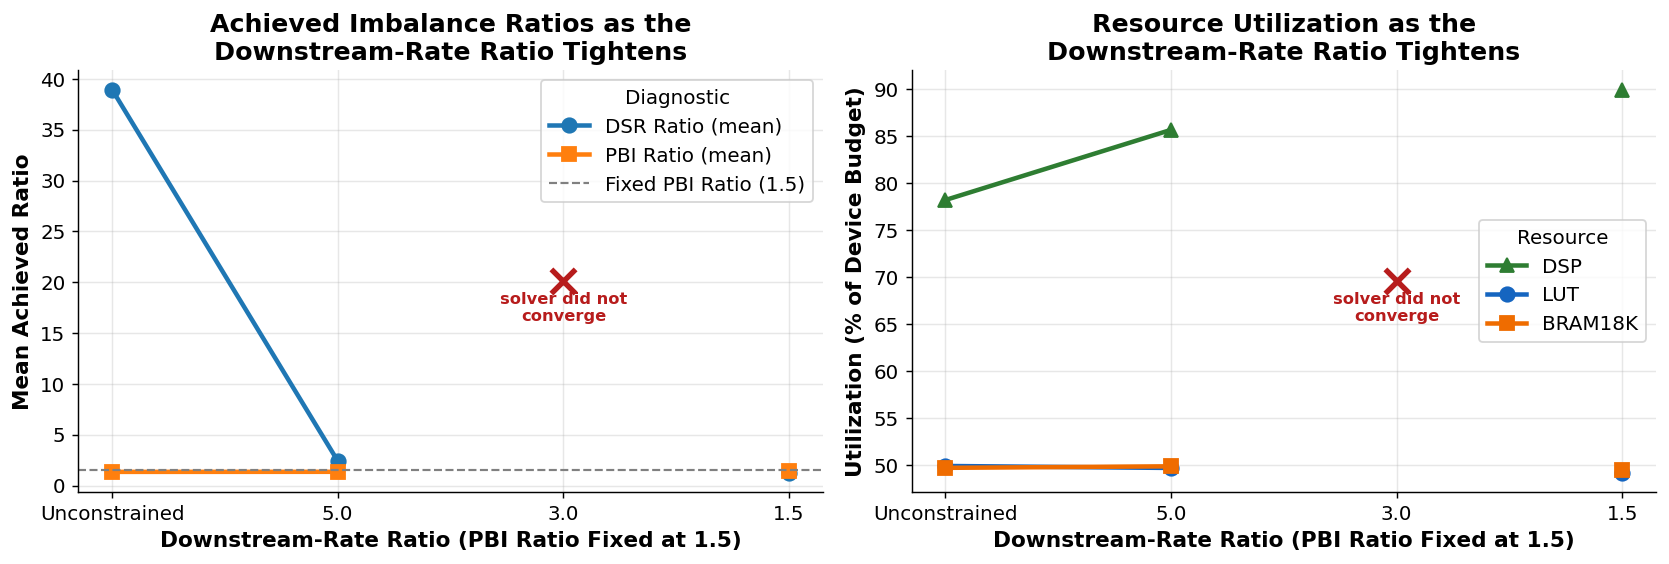

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(df_a["x_label"], df_a["cri_mean_ratio"], marker="o", linewidth=2.5, markersize=8, label="DSR Ratio (mean)")
axes[0].plot(df_a["x_label"], df_a["bi_mean_ratio"], marker="s", linewidth=2.5, markersize=8, label="PBI Ratio (mean)")
axes[0].axhline(1.5, color="grey", linestyle="--", linewidth=1.2, label="Fixed PBI Ratio (1.5)")
axes[0].set_title("Achieved Imbalance Ratios as the\nDownstream-Rate Ratio Tightens")
axes[0].set_xlabel("Downstream-Rate Ratio (PBI Ratio Fixed at 1.5)")
axes[0].set_ylabel("Mean Achieved Ratio")
axes[0].legend(title="Diagnostic", frameon=True)

axes[1].plot(df_a["x_label"], df_a["dsp_pct"], marker="^", linewidth=2.5, markersize=8, color="#2E7D32", label="DSP")
axes[1].plot(df_a["x_label"], df_a["lut_pct"], marker="o", linewidth=2.5, markersize=8, color="#1565C0", label="LUT")
axes[1].plot(df_a["x_label"], df_a["bram_pct"], marker="s", linewidth=2.5, markersize=8, color="#EF6C00", label="BRAM18K")
axes[1].set_title("Resource Utilization as the\nDownstream-Rate Ratio Tightens")
axes[1].set_xlabel("Downstream-Rate Ratio (PBI Ratio Fixed at 1.5)")
axes[1].set_ylabel("Utilization (% of Device Budget)")
axes[1].legend(title="Resource", frameon=True)

# sweepA_pbiFix1.5_dsr3.0 never solved (CBC status "Not Solved", not a clean
# Infeasible, even at an extended 1800s time limit) -- mark the gap on both
# panels instead of silently leaving a hole in the line.
unsolved_a = df_a.index[df_a["status"] == "NotSolved"]
for ax in axes:
    ylo, yhi = ax.get_ylim()
    ymark = ylo + 0.5 * (yhi - ylo)
    for tag in unsolved_a:
        xpos = df_a.loc[tag, "x_label"]
        ax.scatter([xpos], [ymark], marker="x", s=180, color="#B71C1C", linewidth=3, zorder=6)
        ax.annotate("solver did not\nconverge", (xpos, ymark), xytext=(0, -22), textcoords="offset points",
                    ha="center", color="#B71C1C", fontsize=9, fontweight="bold")
    ax.set_ylim(ylo, yhi)

fig.tight_layout()
fig.savefig(FIG_DIR / "sweepA_summary.png", bbox_inches="tight")
plt.show()


## Sweep B: Enforced Downstream-Rate Ratio Fixed at 1.5, Branch-Imbalance (PBI) Ratio Tightening

The mirror of Sweep A.

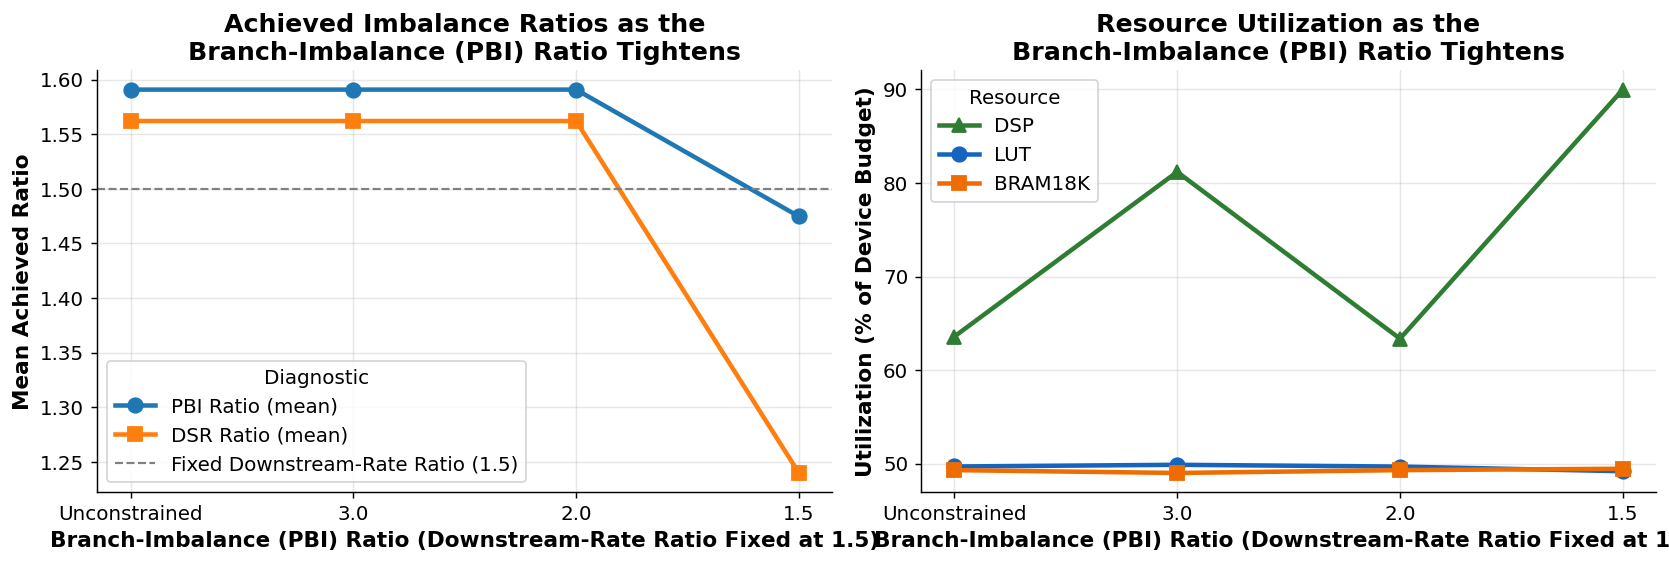

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(df_b["x_label"], df_b["bi_mean_ratio"], marker="o", linewidth=2.5, markersize=8, label="PBI Ratio (mean)")
axes[0].plot(df_b["x_label"], df_b["cri_mean_ratio"], marker="s", linewidth=2.5, markersize=8, label="DSR Ratio (mean)")
axes[0].axhline(1.5, color="grey", linestyle="--", linewidth=1.2, label="Fixed Downstream-Rate Ratio (1.5)")
axes[0].set_title("Achieved Imbalance Ratios as the\nBranch-Imbalance (PBI) Ratio Tightens")
axes[0].set_xlabel("Branch-Imbalance (PBI) Ratio (Downstream-Rate Ratio Fixed at 1.5)")
axes[0].set_ylabel("Mean Achieved Ratio")
axes[0].legend(title="Diagnostic", frameon=True)

axes[1].plot(df_b["x_label"], df_b["dsp_pct"], marker="^", linewidth=2.5, markersize=8, color="#2E7D32", label="DSP")
axes[1].plot(df_b["x_label"], df_b["lut_pct"], marker="o", linewidth=2.5, markersize=8, color="#1565C0", label="LUT")
axes[1].plot(df_b["x_label"], df_b["bram_pct"], marker="s", linewidth=2.5, markersize=8, color="#EF6C00", label="BRAM18K")
axes[1].set_title("Resource Utilization as the\nBranch-Imbalance (PBI) Ratio Tightens")
axes[1].set_xlabel("Branch-Imbalance (PBI) Ratio (Downstream-Rate Ratio Fixed at 1.5)")
axes[1].set_ylabel("Utilization (% of Device Budget)")
axes[1].legend(title="Resource", frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "sweepB_summary.png", bbox_inches="tight")
plt.show()


## Sweep C: Branch-Imbalance (PBI) Ratio Left Unconstrained, Downstream-Rate Ratio Swept Alone

`--pbi-ratio` is never set here. Does tightening `--dsr-ratio` by itself move
the branch-imbalance diagnostic as a side effect?

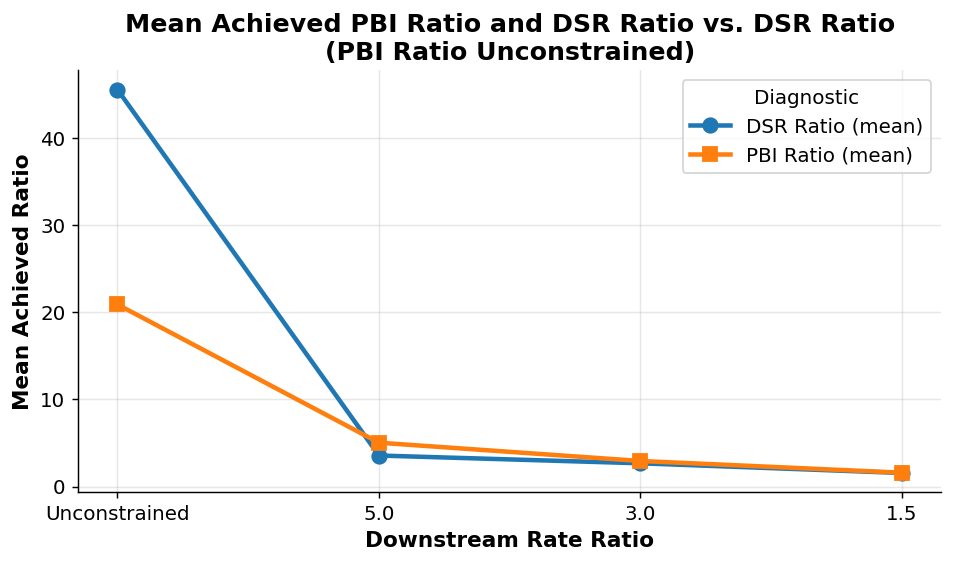

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(df_c["x_label"], df_c["cri_mean_ratio"], marker="o", linewidth=2.5, markersize=8, label="DSR Ratio (mean)")
ax.plot(df_c["x_label"], df_c["bi_mean_ratio"], marker="s", linewidth=2.5, markersize=8, label="PBI Ratio (mean)")
ax.set_title("Mean Achieved PBI Ratio and DSR Ratio vs. DSR Ratio\n(PBI Ratio Unconstrained)")
ax.set_xlabel("Downstream Rate Ratio")
ax.set_ylabel("Mean Achieved Ratio")
ax.legend(title="Diagnostic", frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "sweepC_summary.png", bbox_inches="tight")
plt.show()


## Sweep D: Downstream-Rate Ratio Left Unconstrained, Branch-Imbalance (PBI) Ratio Swept Alone

`--dsr-ratio` is never set here. Does tightening `--pbi-ratio` by itself move
the chain-rate-imbalance diagnostic as a side effect?

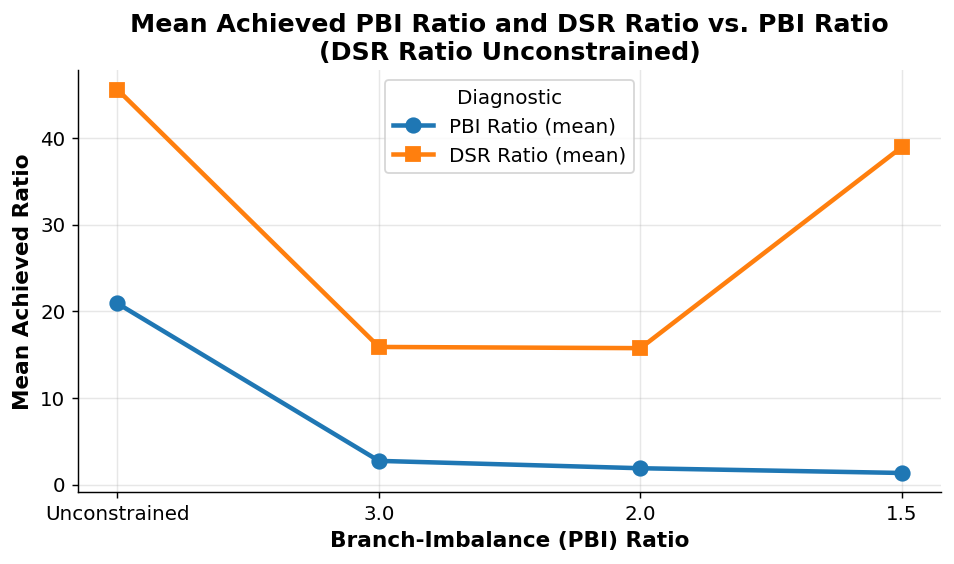

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(df_d["x_label"], df_d["bi_mean_ratio"], marker="o", linewidth=2.5, markersize=8, label="PBI Ratio (mean)")
ax.plot(df_d["x_label"], df_d["cri_mean_ratio"], marker="s", linewidth=2.5, markersize=8, label="DSR Ratio (mean)")
ax.set_title("Mean Achieved PBI Ratio and DSR Ratio vs. PBI Ratio\n(DSR Ratio Unconstrained)")
ax.set_xlabel("Branch-Imbalance (PBI) Ratio")
ax.set_ylabel("Mean Achieved Ratio")
ax.legend(title="Diagnostic", frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "sweepD_summary.png", bbox_inches="tight")
plt.show()


## Interpretation

All figures and numbers below use the MEAN achieved ratio across diamonds/nodes
(not the median used in an earlier draft of this notebook) -- the median was
originally chosen for robustness against a handful of fixed-cycle-exempt
outlier nodes (e.g. `up4.upsample` at 576x for chain-rate, a MaxPool/concat
fork at 1.8x for branch-imbalance -- these nodes have no folding freedom, so
they sit outside either ratio's own reach regardless of how tight it is set).
In practice mean and median tell the same story here (e.g. baseline PBI
20.9 mean vs. 22.0 median, DSR 45.6 mean vs. 46.8 median), so the switch to
mean does not change any conclusion, only the exact numbers cited.

**Terminology note:** "join imbalance" / "join-balance ratio" is a deprecated
name for `--pbi-ratio`'s target metric, left over from before the 2026-09-29
fix. `--pbi-ratio` ("parallel branch imbalance") constrains the FULL
fork-to-join branch cycle-sum on both sides of a diamond, not just the single
node immediately preceding the join -- see this notebook's opening cell and
`MILP/finn_milp.md`'s "Rate coherence" section. Below, "PBI ratio" always
means this branch-imbalance metric (the `branch_imbalance` diagnostic); "DSR
ratio" always means the chain-rate-coherence metric (the
`chain_rate_imbalance` diagnostic).

**Sweep C (DSR ratio swept alone, PBI ratio never constrained)** shows
`--dsr-ratio` acting as a strong, monotonic regularizer on BOTH diagnostics
even though `--pbi-ratio` is never touched: from the fully unconstrained
baseline (PBI ratio 20.9, DSR ratio 45.6, both mean), `--dsr-ratio 5.0` alone
already brings both down to 5.04 / 3.56, `--dsr-ratio 3.0` to 2.94 / 2.67, and
`--dsr-ratio 1.5` to 1.59 / 1.56 -- landing almost exactly at its own cap on
both metrics as a free side effect.

**Sweep D (PBI ratio swept alone, DSR ratio never constrained)** shows the
opposite asymmetry: `--pbi-ratio` reliably controls its OWN diagnostic (PBI
ratio falls monotonically, 20.9 to 2.74 to 1.90 to 1.35 as `--pbi-ratio`
tightens from unconstrained to 1.5), but DSR ratio is NOT reliably controlled
as a side effect -- it drops from 45.6 to ~15.8 at `--pbi-ratio` 3.0/2.0, then
rises sharply back to 38.95 at the tightest setting (`--pbi-ratio` 1.5).
Tightening PBI past a point actively *worsens* DSR coherence here, because
the solver is free to trade any remaining folding slack away from chain
coherence once PBI alone is binding.

**Sweep B (DSR ratio fixed at 1.5, PBI ratio swept)** confirms `--pbi-ratio`
is largely inert once `--dsr-ratio` is already active: PBI ratio stays flat
at 1.59 (exactly `--dsr-ratio`'s own natural byproduct from Sweep C) across
`--pbi-ratio` unconstrained/3.0/2.0 -- none of these are tight enough to
bind, since dsr alone already achieves 1.59. Only `--pbi-ratio 1.5` (tighter
than dsr's own 1.59 byproduct) has any effect at all, and even then the gain
is small (PBI ratio 1.59 to 1.475, DSR ratio 1.56 to 1.24) for a real DSP
cost (63.6% to 90.0% of budget).

**Sweep A (PBI ratio fixed at 1.5, DSR ratio swept)** is missing its
`--dsr-ratio 3.0` point: CBC returned solver status "Not Solved" (not a clean
Infeasible) at this specific combined-constraint point, even at an extended
1800s time limit (default 600s) -- it never produced an incumbent or a proof
of infeasibility. The three points that did solve are consistent with
Sweeps C/D's story: `--dsr-ratio` off (pbi=1.5 alone) leaves DSR ratio at
38.95 (matching Sweep D's own pbi=1.5 point exactly), but even a *loose*
`--dsr-ratio 5.0` brings it down to 2.42 -- almost all of the DSR-coherence
benefit is captured by turning `--dsr-ratio` on at all, regardless of how
tight.

**Conclusion on redundancy.** `--dsr-ratio` is the dominant, load-bearing
mechanism for this architecture: alone, it drives both diagnostics down
together, because chain-rate coherence is the more encompassing physical
constraint (branch cycle sums are sub-chains of the same node-to-node rate
structure it directly controls). `--pbi-ratio` alone is largely redundant
*for achieving DSR coherence specifically* -- it does not reliably help DSR
ratio, and can measurably hurt it when tightened aggressively (Sweep D,
pbi=1.5). However, `--pbi-ratio` is not *entirely* redundant in an absolute
sense: layered on top of an already-tight `--dsr-ratio 1.5`, it still buys a
further real tightening of PBI ratio specifically (1.59 to 1.475, Sweep
A/B's shared dsr=1.5,pbi=1.5 point) that `--dsr-ratio` alone does not reach
(1.59, Sweep C's dsr=1.5-alone point) -- a modest but genuine incremental
effect, at a real DSP cost.

**For the FIFO-BRAM hardware validation:** this argues `--dsr-ratio` is the
higher-priority axis to validate against real synthesized FIFO BRAM (it is
doing essentially all of the work), while `--pbi-ratio`'s hardware effect, if
tested, should be expected to be small and secondary -- worth a validation
point since it is not zero, but not an equal, independently-weighted
ablation alongside `--dsr-ratio`.